<a href="https://colab.research.google.com/github/meganjohnson0522/INFO648/blob/main/Homeworks/Homework_3_Info_648.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.stats import ttest_ind, ttest_1samp

In [ ]:
#We need to read in our data to the active python session - we will read it directly into a data frame.
df = pd.read_csv('/content/cps_with_education-1 (1).csv')
df.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
0,0,2020,40,0.0,63,2,23,Some College
1,1,2020,999,0.0,67,1,23,Some College
2,2,2020,48,654.0,64,1,23,Some College
3,3,2020,999,0.0,71,2,23,Less than HS
4,4,2020,44,0.0,54,2,23,Some College


In [ ]:
df_clean= df[(df['EARNWEEK2']<99999) & (df['EARNWEEK2']>0)&(df['YEAR']>2023)].copy()

df_clean.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
3076326,3076326,2024,40,520.0,36,1,1,Some College
3076330,3076330,2024,40,700.0,23,2,1,Some College
3076332,3076332,2024,35,516.0,64,2,1,Some College
3076333,3076333,2024,40,720.0,57,2,1,Some College
3076334,3076334,2024,12,220.0,69,1,1,Some College


In [ ]:
print(df_clean['YEAR'].unique())

[2024 2025]


In [ ]:
men_2024 = df_clean[(df_clean['SEX'] == 1) & (df_clean['YEAR'] == 2024)].copy()
men_2025 = df_clean[(df_clean['SEX'] == 1) & (df_clean['YEAR'] == 2025)].copy()
women_2024 = df_clean[(df_clean['SEX'] == 2) & (df_clean['YEAR'] == 2024)].copy()
women_2025 = df_clean[(df_clean['SEX'] == 2) & (df_clean['YEAR'] == 2025)].copy()

##PART A

In [ ]:
men_2024_cut = men_2024['EARNWEEK2'].quantile(0.95)
men_2025_cut = men_2025['EARNWEEK2'].quantile(0.95)
women_2024_cut = women_2024['EARNWEEK2'].quantile(0.95)
women_2025_cut = women_2025['EARNWEEK2'].quantile(0.95)

print(men_2024_cut, men_2025_cut, women_2024_cut, women_2025_cut)

3660.0 3860.0 2880.0 2975.9999999999127


In [ ]:
# We will code this together, for each dataframe it is two steps:
men_2024['EARNWEEK2_w95'] = men_2024['EARNWEEK2']
men_2024.loc[men_2024['EARNWEEK2'] > men_2024_cut, 'EARNWEEK2_w95'] = men_2024_cut

men_2025['EARNWEEK2_w95'] = men_2025['EARNWEEK2']
men_2025.loc[men_2025['EARNWEEK2'] > men_2025_cut, 'EARNWEEK2_w95'] = men_2025_cut

women_2024['EARNWEEK2_w95'] = women_2024['EARNWEEK2']
women_2024.loc[women_2024['EARNWEEK2'] > women_2024_cut, 'EARNWEEK2_w95'] = women_2024_cut

women_2025['EARNWEEK2_w95'] = women_2025['EARNWEEK2']
women_2025.loc[women_2025['EARNWEEK2'] > women_2025_cut, 'EARNWEEK2_w95'] = women_2025_cut

print(len(men_2024), len(men_2025), len(women_2024), len(women_2025))

66587 55953 64001 53705


In [ ]:
print("Part A Deliverable")
print(f"{'Group':<15} {'Cutoff (cg)':<15} {'Sample Size (ng)'}")
print("-" * 50)
print(f"{'Men 2024':<15} ${men_2024_cut:<14.2f} {len(men_2024)}")
print(f"{'Men 2025':<15} ${men_2025_cut:<14.2f} {len(men_2025)}")
print(f"{'Women 2024':<15} ${women_2024_cut:<14.2f} {len(women_2024)}")
print(f"{'Women 2025':<15} ${women_2025_cut:<14.2f} {len(women_2025)}")

Part A Deliverable
Group           Cutoff (cg)     Sample Size (ng)
--------------------------------------------------
Men 2024        $3660.00        66587
Men 2025        $3860.00        55953
Women 2024      $2880.00        64001
Women 2025      $2976.00        53705


##PART B

In [ ]:
z = norm.ppf(1 - 0.025)

In [ ]:
# Men 2024
n_m24 = len(men_2024['EARNWEEK2_w95'])
mean_m24 = men_2024['EARNWEEK2_w95'].mean()
std_m24 = men_2024['EARNWEEK2_w95'].std()

ci_lower_m24 = mean_m24 - z * (std_m24 / np.sqrt(n_m24))
ci_upper_m24 = mean_m24 + z * (std_m24 / np.sqrt(n_m24))

print(f"Men 2024: ({ci_lower_m24:.2f}, {ci_upper_m24:.2f})")

Men 2024: (1404.82, 1418.72)


In [ ]:
# Men 2025
n_m25 = len(men_2025['EARNWEEK2_w95'])
mean_m25 = men_2025['EARNWEEK2_w95'].mean()
std_m25 = men_2025['EARNWEEK2_w95'].std()

ci_lower_m25 = mean_m25 - z * (std_m25 / np.sqrt(n_m25))
ci_upper_m25 = mean_m25 + z * (std_m25 / np.sqrt(n_m25))

print(f"Men 2025: ({ci_lower_m25:.2f}, {ci_upper_m25:.2f})")

Men 2025: (1475.07, 1491.30)


In [ ]:
# Women 2024
n_w24 = len(women_2024['EARNWEEK2_w95'])
mean_w24 = women_2024['EARNWEEK2_w95'].mean()
std_w24 = women_2024['EARNWEEK2_w95'].std()

ci_lower_w24 = mean_w24 - z * (std_w24 / np.sqrt(n_w24))
ci_upper_w24 = mean_w24 + z * (std_w24 / np.sqrt(n_w24))

print(f"Women 2024: ({ci_lower_w24:.2f}, {ci_upper_w24:.2f})")

Women 2024: (1086.34, 1097.53)


In [ ]:
# Women 2025
n_w25 = len(women_2025['EARNWEEK2_w95'])
mean_w25 = women_2025['EARNWEEK2_w95'].mean()
std_w25 = women_2025['EARNWEEK2_w95'].std()

ci_lower_w25 = mean_w25 - z * (std_w25 / np.sqrt(n_w25))
ci_upper_w25 = mean_w25 + z * (std_w25 / np.sqrt(n_w25))

print(f"Women 2025: ({ci_lower_w25:.2f}, {ci_upper_w25:.2f})")

Women 2025: (1122.38, 1135.04)


For men, the 2024 95% confidence interval of 1404.82 - 1418.72 and the 2025 confidence interval of 1475.07 - 1491.30 do not overlap, which means there was an increase in population mean weekly earnings from 2024 to 2025. For women, the 2024 confidence interval of 1086.34 - 1097.53 and the 2025 confidence interval of 1122.38 - 1135.04 also do not overlap, indicating a similar increase from 2024 to 2025. The non-overlapping intervals for both shows strong evidence that mean earnings increased from 2024 to 2025 for both groups.

##PART C

In [ ]:
# Ho: Mean winsorized weekly earnings for men: 2024 = 2025
# Ha: Mean winsorized weekly earnings for men: 2024 ≠ 2025

ttest_ind(men_2024['EARNWEEK2_w95'], men_2025['EARNWEEK2_w95'], alternative='two-sided')

TtestResult(statistic=np.float64(-13.17771992991983), pvalue=np.float64(1.2546297636702773e-39), df=np.float64(122538.0))

In [ ]:
# Ho: Mean winsorized weekly earnings for women: 2024 = 2025
# Ha: Mean winsorized weekly earnings for women: 2024 ≠ 2025

ttest_ind(women_2024['EARNWEEK2_w95'], women_2025['EARNWEEK2_w95'], alternative='two-sided')

TtestResult(statistic=np.float64(-8.556816737026322), pvalue=np.float64(1.1739118675121105e-17), df=np.float64(117704.0))

We reject H0 at α = 0.05 for men (p = 1.25e-39), concluding that the mean winsorized weekly earnings for men significantly changed from 2024 to 2025.

We also reject H0 at α = 0.05 for women (p = 1.74e-17), concluding that the mean winsorized weekly earnings for women also significantly changed from 2024 to 2025.

##PART D

In [ ]:
# percent change in the winsorized mean

pct_change_men = (mean_m25 - mean_m24) / mean_m24 * 100
print(f"Men % Change: {pct_change_men:.2f}%")

pct_change_women = (mean_w25 - mean_w24) / mean_w24 * 100
print(f"Women % Change: {pct_change_women:.2f}%")

Men % Change: 5.06%
Women % Change: 3.37%


In [ ]:
# Cohen's d using the pooled standard deviation sp

# Cohen's d for men
sp_men = np.sqrt(((n_m24 - 1) * std_m24**2 + (n_m25 - 1) * std_m25**2) / (n_m24 + n_m25 - 2))
d_men = (mean_m25 - mean_m24) / sp_men
print(f"Cohen's d for Men: {d_men:.4f}")

# Cohen's d for women
sp_women = np.sqrt(((n_w24 - 1) * std_w24**2 + (n_w25 - 1) * std_w25**2) / (n_w24 + n_w25 - 2))
d_women = (mean_w25 - mean_w24) / sp_women
print(f"Cohen's d for Women: {d_women:.4f}")


Cohen's d for Men: 0.0756
Cohen's d for Women: 0.0501


Cohen's d for men is 0.0756 and for women is 0.0501, both of which are less than the 0.2 threshold and therefore classified as small effects. Despite the extremely small p-values from Part C (1.25e-39 for men and 1.74e-17 for women), the actual differences in mean earnings are small relative to the spread of earnings. This illustrates the key distinction between statistical significance and practical significance, with very large samples, the standard error becomes so small differences produce near-zero p-values. While we can be confident the population mean earnings changed from 2024 to 2025 for both sexes, the change is small and may not be meaningful in everyday economic terms.

##PART E

Men's winsorized mean weekly earnings grew by 5.06% from 2024 to 2025, and women's winsorized mean weekly earnings grew by 3.37%, which both are greater than the assumed CPI increase of 2.7%. This means that both groups earnings are likely keeping with inflation for 2024-2025.Looking at the percent changes men's earnings grew faster than women's suggesting men experienced stronger real wage growth from 2024 to 2025. However, these figures reflect population mean winsorized earnings, so individual experiences will vary, and winsorization removes the top earners which could cause a slight understatement of true growth.


##PART F

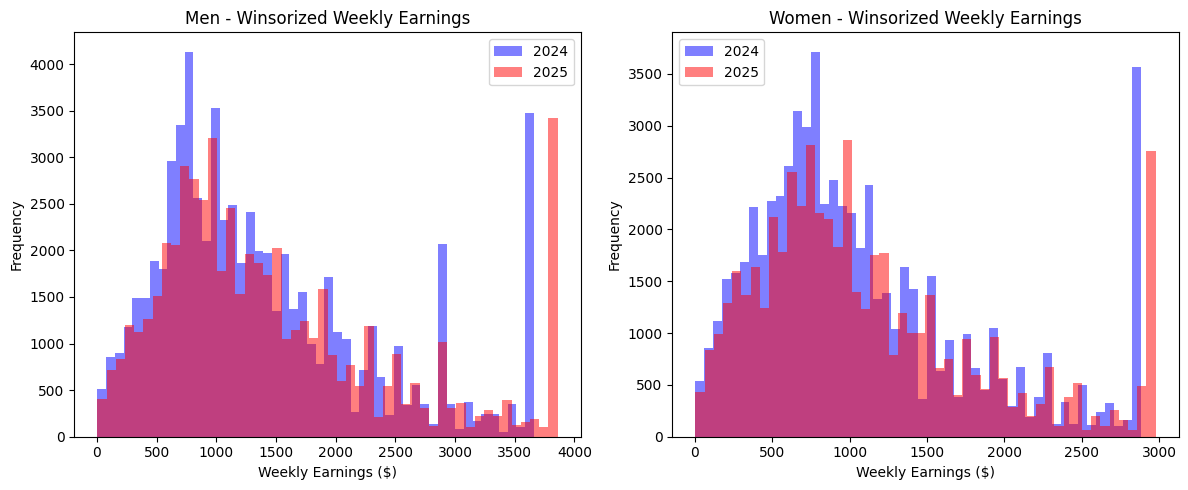

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Men
axes[0].hist(men_2024['EARNWEEK2_w95'], bins=50, alpha=0.5, label='2024', color='blue')
axes[0].hist(men_2025['EARNWEEK2_w95'], bins=50, alpha=0.5, label='2025', color='red')
axes[0].set_title('Men - Winsorized Weekly Earnings')
axes[0].set_xlabel('Weekly Earnings ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Women
axes[1].hist(women_2024['EARNWEEK2_w95'], bins=50, alpha=0.5, label='2024', color='blue')
axes[1].hist(women_2025['EARNWEEK2_w95'], bins=50, alpha=0.5, label='2025', color='red')
axes[1].set_title('Women - Winsorized Weekly Earnings')
axes[1].set_xlabel('Weekly Earnings ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

Both distributions are right skewed with a large spike at the winsorized cutoff on the far right, confirming that winsorization successfully capped the high earners. The histograms also show that the 2024 and 2025 distributions overlap heavily for both men and women, meaning the yearly shift in earnings is subtle.

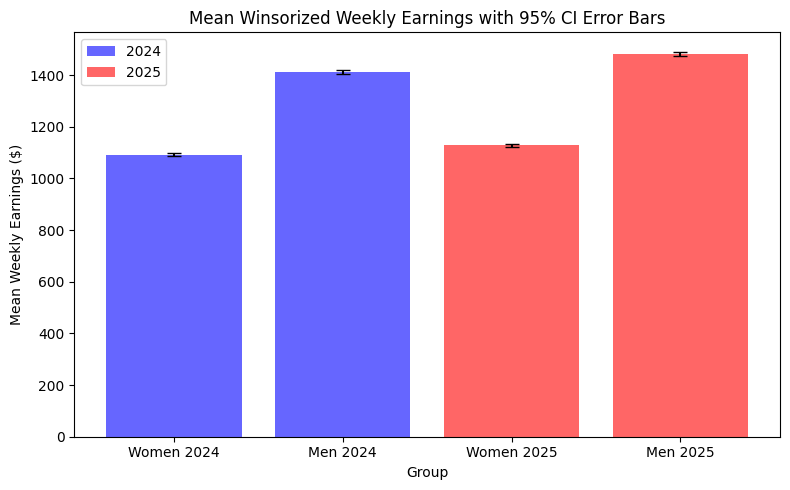

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

groups = ['Women 2024', 'Men 2024', 'Women 2025', 'Men 2025']
means = [mean_w24, mean_m24, mean_w25, mean_m25]
ci_errors = [
    (mean_w24 - ci_lower_w24),
    (mean_m24 - ci_lower_m24),
    (mean_w25 - ci_lower_w25),
    (mean_m25 - ci_lower_m25)
]

bars = ax.bar(groups, means, yerr=ci_errors, capsize=5, color=['blue','blue','red','red'], alpha=0.6)
ax.set_title('Mean Winsorized Weekly Earnings with 95% CI Error Bars')
ax.set_xlabel('Group')
ax.set_ylabel('Mean Weekly Earnings ($)')

# Manually create legend handles
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.6, label='2024'),
                   Patch(facecolor='red', alpha=0.6, label='2025')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

The bar plot makes clear that men earn substantially more than women in both years, a gap that the summary numbers alone don't visually emphasize. Notably, the 95% confidence interval error bars are nearly invisible relative to the bar heights, showing how we can accurately estimate the population means with these large sample sizes.